# Random Forest Classification Analysis for Heart Disease Prediction
**Machine Learning Assignment — Member 3**  
**Algorithm: Random Forest (Binary Classification)**

---

In [3]:
# Core libraries for data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Utilities for splitting, preprocessing, tuning, and evaluating the model
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

## Data Loading and Parsing
Read the dataset and convert multi-class diagnosis to binary heart disease labels.

In [4]:
# Load the heart dataset from the project data folder
df = pd.read_csv('../data/heart_disease_uci.csv')

# Convert the original diagnosis into a binary target label
X = df.drop(['num', 'id', 'dataset'], axis=1)
y = (df['num'] > 0).astype(int)

# Identify numeric and categorical columns for preprocessing
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print('Dataset shape:', df.shape)
print('Feature shape:', X.shape)
print('Positive class ratio:', round(y.mean(), 3))

Dataset shape: (920, 16)
Feature shape: (920, 13)
Positive class ratio: 0.553


## Data Cleaning and Preprocessing
Use imputation and one-hot encoding in a consistent preprocessing pipeline.

In [5]:
# Split the data into training and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Separate numeric and categorical columns so each can be processed appropriately
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Build preprocessing pipelines for numeric and categorical data
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

# Combine preprocessing steps into one transformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features),
])

## Model Training and Baseline Evaluation
Train a baseline random forest model and report key classification metrics.

In [6]:
# Define a reusable evaluation helper for predictions and probabilities
def evaluate_model(model, X_eval, y_eval, title):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    metrics = {
        "acc": accuracy_score(y_eval, y_pred),
        "prec": precision_score(y_eval, y_pred, zero_division=0),
        "rec": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "auc": roc_auc_score(y_eval, y_prob),
    }

    print(title)
    print(f"Accuracy : {metrics['acc']:.4f}")
    print(f"Precision: {metrics['prec']:.4f}")
    print(f"Recall   : {metrics['rec']:.4f}")
    print(f"F1-score : {metrics['f1']:.4f}")
    print(f"ROC-AUC  : {metrics['auc']:.4f}")

    print("\nConfusion Matrix:\n", confusion_matrix(y_eval, y_pred))
    print("\nClassification Report:\n", classification_report(y_eval, y_pred, zero_division=0))

    return y_pred, y_prob, metrics

# Train the baseline random forest pipeline
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42)),
])

baseline_model.fit(X_train, y_train)
base_pred, base_prob, baseline_metrics = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    "Baseline Random Forest Results",
)

Baseline Random Forest Results
Accuracy : 0.8478
Precision: 0.8491
Recall   : 0.8824
F1-score : 0.8654
ROC-AUC  : 0.9198

Confusion Matrix:
 [[66 16]
 [12 90]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.80      0.82        82
           1       0.85      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



## Hyperparameter Tuning
Tune tree count and regularization-related settings with stratified cross-validation.

In [7]:
# Search a smaller hyperparameter space so tuning finishes faster
param_distributions = {
    'model__n_estimators': [100, 150, 200],
    'model__max_depth': [None, 10, 15],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__class_weight': [None, 'balanced']
}

# Use fewer folds and randomized search to reduce total fit time
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = RandomizedSearchCV(
    baseline_model,
    param_distributions=param_distributions,
    n_iter=12,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print('Best parameters:', grid_search.best_params_)
print('Best CV F1:', round(grid_search.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 10, 'model__class_weight': None}
Best CV F1: 0.8502


In [8]:
# Evaluate the tuned random forest model on the holdout test set
best_pred, best_prob, tuned_metrics = evaluate_model(
    best_model,
    X_test,
    y_test,
    "Tuned Random Forest Results",
)

# Compare baseline and tuned metrics side by side
summary_df = pd.DataFrame([
    {"model": "baseline", **baseline_metrics},
    {"model": "tuned", **tuned_metrics},
]).set_index("model")

print("\nRandom Forest Summary Table:")
print(summary_df.round(4))

Tuned Random Forest Results
Accuracy : 0.8641
Precision: 0.8532
Recall   : 0.9118
F1-score : 0.8815
ROC-AUC  : 0.9225

Confusion Matrix:
 [[66 16]
 [ 9 93]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.80      0.84        82
           1       0.85      0.91      0.88       102

    accuracy                           0.86       184
   macro avg       0.87      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184


Random Forest Summary Table:
             acc    prec     rec      f1     auc
model                                           
baseline  0.8478  0.8491  0.8824  0.8654  0.9198
tuned     0.8641  0.8532  0.9118  0.8815  0.9225


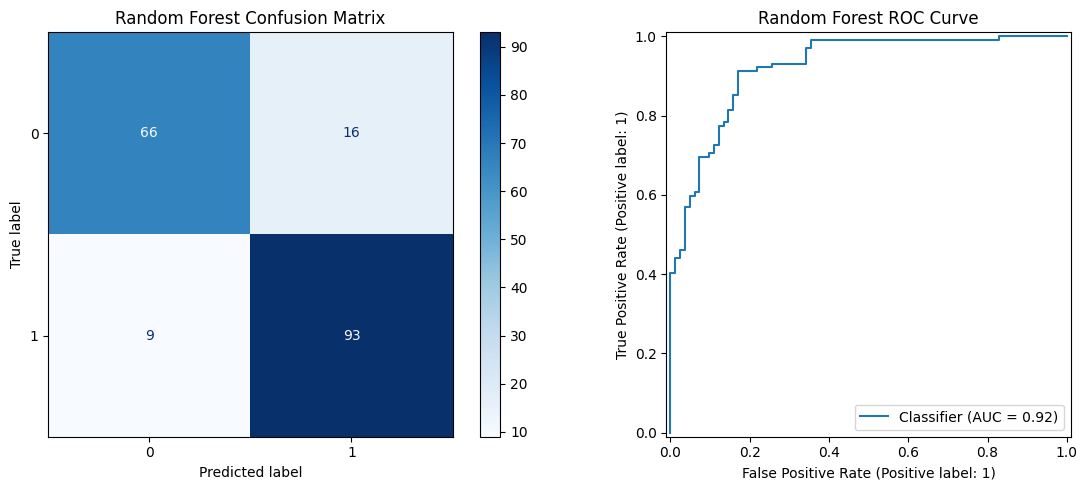


Top 10 Feature Importances:
               feature  importance
2                 chol    0.125414
8      cp_asymptomatic    0.103194
0                  age    0.103168
3               thalch    0.102167
4              oldpeak    0.084720
18          exang_True    0.081225
1             trestbps    0.061355
9   cp_atypical angina    0.049313
17         exang_False    0.040076
6           sex_Female    0.028748


In [9]:
# Plot the confusion matrix and ROC curve for the tuned model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, ax=axes[0], cmap="Blues")
axes[0].set_title("Random Forest Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, best_prob, ax=axes[1])
axes[1].set_title("Random Forest ROC Curve")
plt.tight_layout()
plt.show()

# Show the most important features from the fitted forest
ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(cat_features).tolist() if len(cat_features) > 0 else []
all_feature_names = num_features + cat_names

importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": best_model.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)

print("\nTop 10 Feature Importances:")
print(importance_df.head(10))

## Patient-Level Prediction Example
Generate a patient-level risk prediction from the tuned model.

In [10]:
# Enter patient details manually (edit values as needed)
sample_patient = pd.DataFrame([{
    "age": 54,
    "sex": "Male",
    "cp": "asymptomatic",
    "trestbps": 140,
    "chol": 239,
    "fbs": "FALSE",
    "restecg": "normal",
    "thalch": 160,
    "exang": "FALSE",
    "oldpeak": 1.2,
    "slope": "flat",
    "ca": 0,
    "thal": "normal",
}])

# Predict disease class and probability for the manual patient input
sample_pred = best_model.predict(sample_patient)[0]
sample_prob = best_model.predict_proba(sample_patient)[0, 1]

print("Predicted class (0=no disease, 1=disease):", int(sample_pred))
print("Predicted disease probability:", round(float(sample_prob), 4))
print("Interpretation: This patient has a {:.2%} chance of heart disease.".format(sample_prob))
print("Model Accuracy on Test Set: {:.2%}".format(tuned_metrics["acc"]))

Predicted class (0=no disease, 1=disease): 1
Predicted disease probability: 0.5964
Interpretation: This patient has a 59.64% chance of heart disease.
Model Accuracy on Test Set: 86.41%
